In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import jax

import os
os.environ["JAX_PLATFORMS"] = "cpu"
print("JAX devices:", jax.devices())


import sys
sys.path.append('./')
import JAXdata_loaders

from importlib import reload
JAXdata_loaders = reload(JAXdata_loaders)

import os
os.environ["JAX_PLATFORMS"] = "cpu"
print("JAX devices:", jax.devices())


JAX devices: [CpuDevice(id=0)]
JAX devices: [CpuDevice(id=0)]


In [4]:
#!/usr/bin/env python

# Core Libraries
import inox                  # Custom library (likely for modeling and random utilities)
inox = reload(inox)
import inox.nn as nn         # Neural network components
import jax                   # JAX for high-performance computing
import optax                 # Optimizers for JAX
import wandb                 # Weights and Biases for experiment tracking

# Data handling
#from datasets import Array3D, Features, load_from_disk
import sys
sys.path.append('./')
import JAXdata_loaders


# Workflow management
from dawgz import job, schedule

# Utils
from functools import partial
from tqdm import trange
from typing import *
from utils import *          # Assumed utility functions (augmentations, flatten, sampling, etc.)


# Dataloaders in JAX

To replicate the behavior of your PyTorch ConcatDataset, random_split, and DataLoader with custom samplers in JAX, we need to reimplement a few components using NumPy/JAX primitives. JAX does not have a native dataloader abstraction like PyTorch, so we handle batching, shuffling, and iteration manually.

Here’s a drop-in JAX-style equivalent:



In [5]:
from importlib import reload
JAXdata_loaders = reload(JAXdata_loaders)

standards = {
                "mean_ssh": 0.0, "std_ssh": 0.0453692672359483,
                "mean_sst": 15.956900367755182, "std_sst": 5.987649544923141
            }

DATA_CONFIG = {
    "data_dir": "/home/tm3076/scratch/pytorch_learning_tiles"  ,
    "N_t": 1,
    "infields": ["zarr_llc4320_SST_tiles_4km","zarr_llc4320_SSH_tiles_4km_filtered"],
    "in_mask_list": ["cloud_rho","swot"],
    "in_transform_list": ["std_global_mean_sst_norm","std_global_mean_ssh_norm"],
    "standards": standards,
    "flatten": False,
    "return_meta_data": False,
    "cloud_rho": 0.5,
}

dataset = JAXdata_loaders.JAXLLC4320_HFformated_dataset(
    patch_coords=f"{DATA_CONFIG['data_dir']}/zarred_UVSST_x_y_coordinates_noland_nonan.npy",
    t_range=range(5, 360, 5),
    split_fractions={"train": 0.75, "val":0.15, "test":0.1},
    config=DATA_CONFIG,  
)

y_train, A_train = dataset["train"][:5]['y'], dataset["train"][:5]['A']

print("y_train.shape",y_train.shape)
print("A_train.shape",A_train.shape)



y_train.shape (5, 128, 128, 2)
A_train.shape (5, 128, 128, 2)


In [7]:
import priors

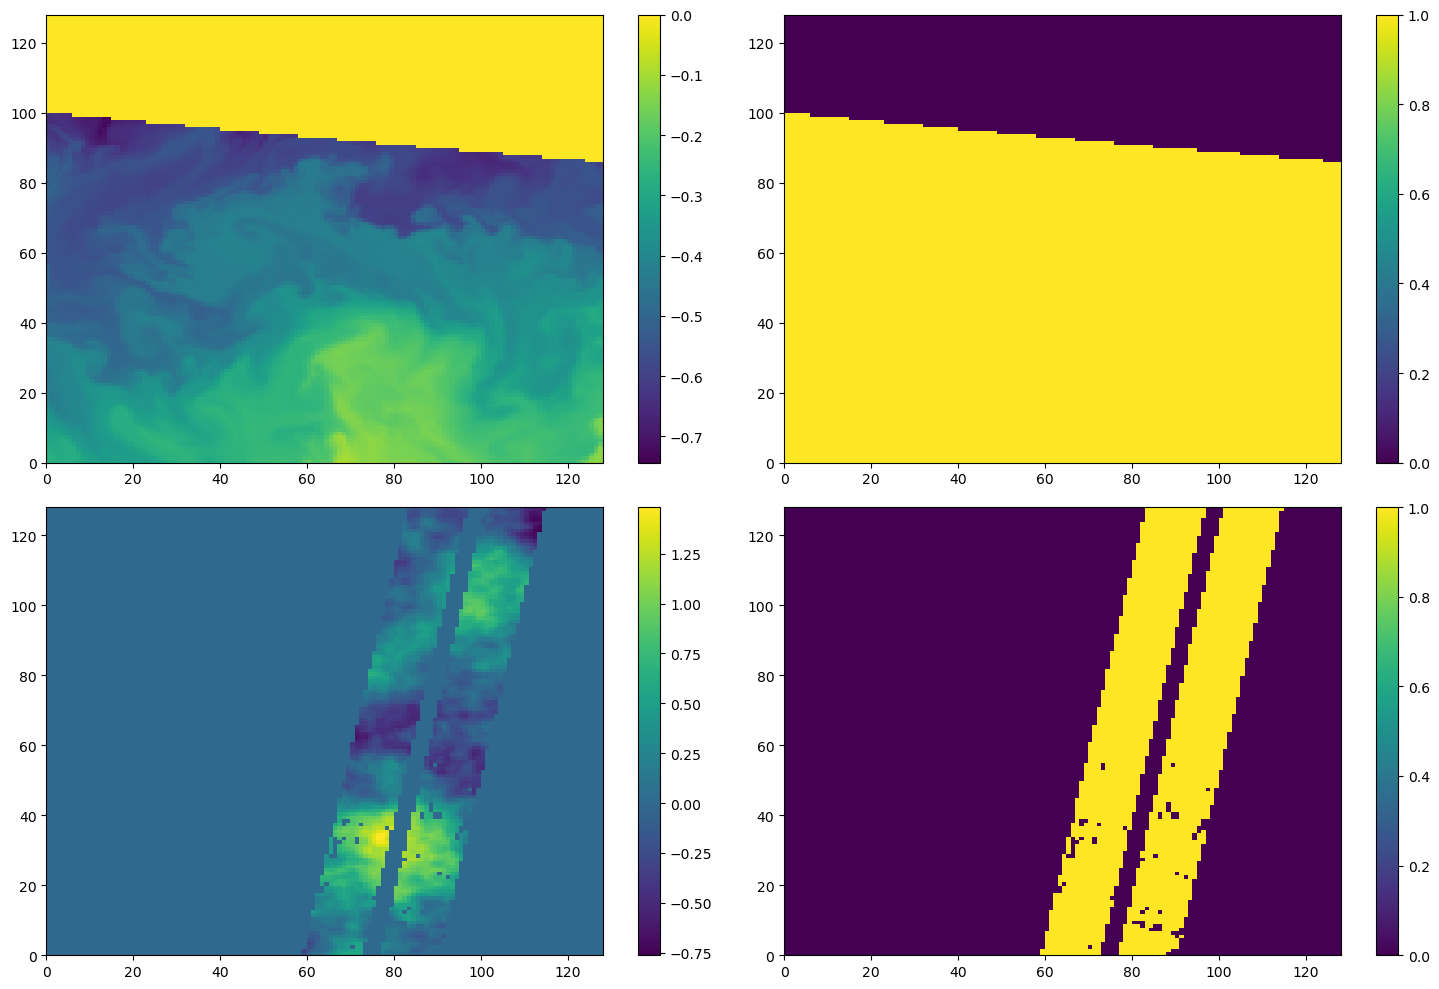

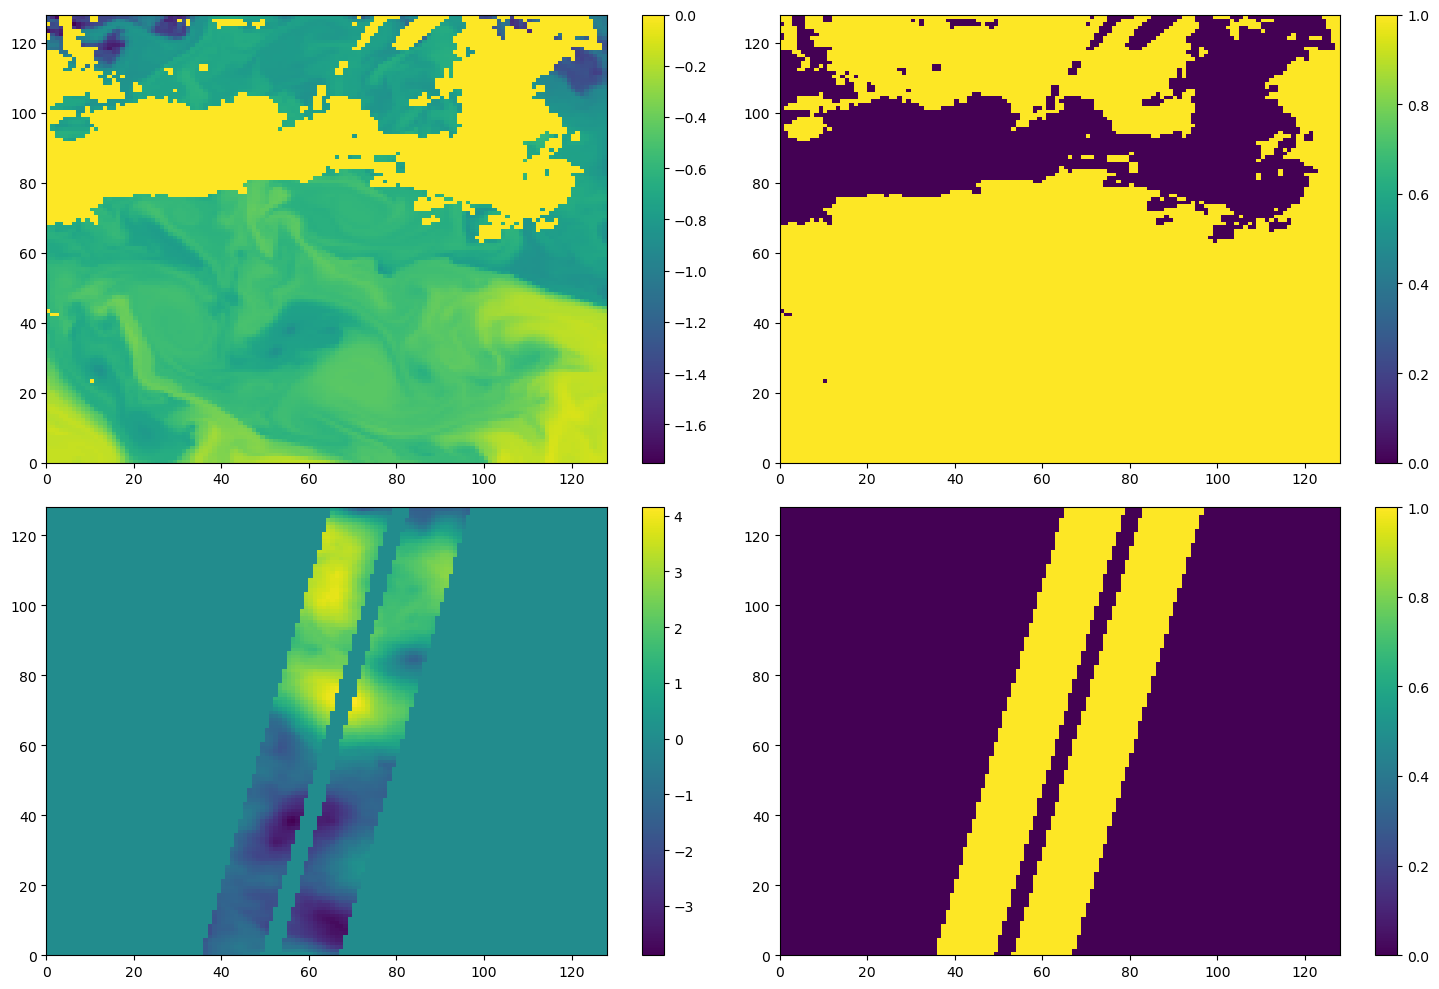

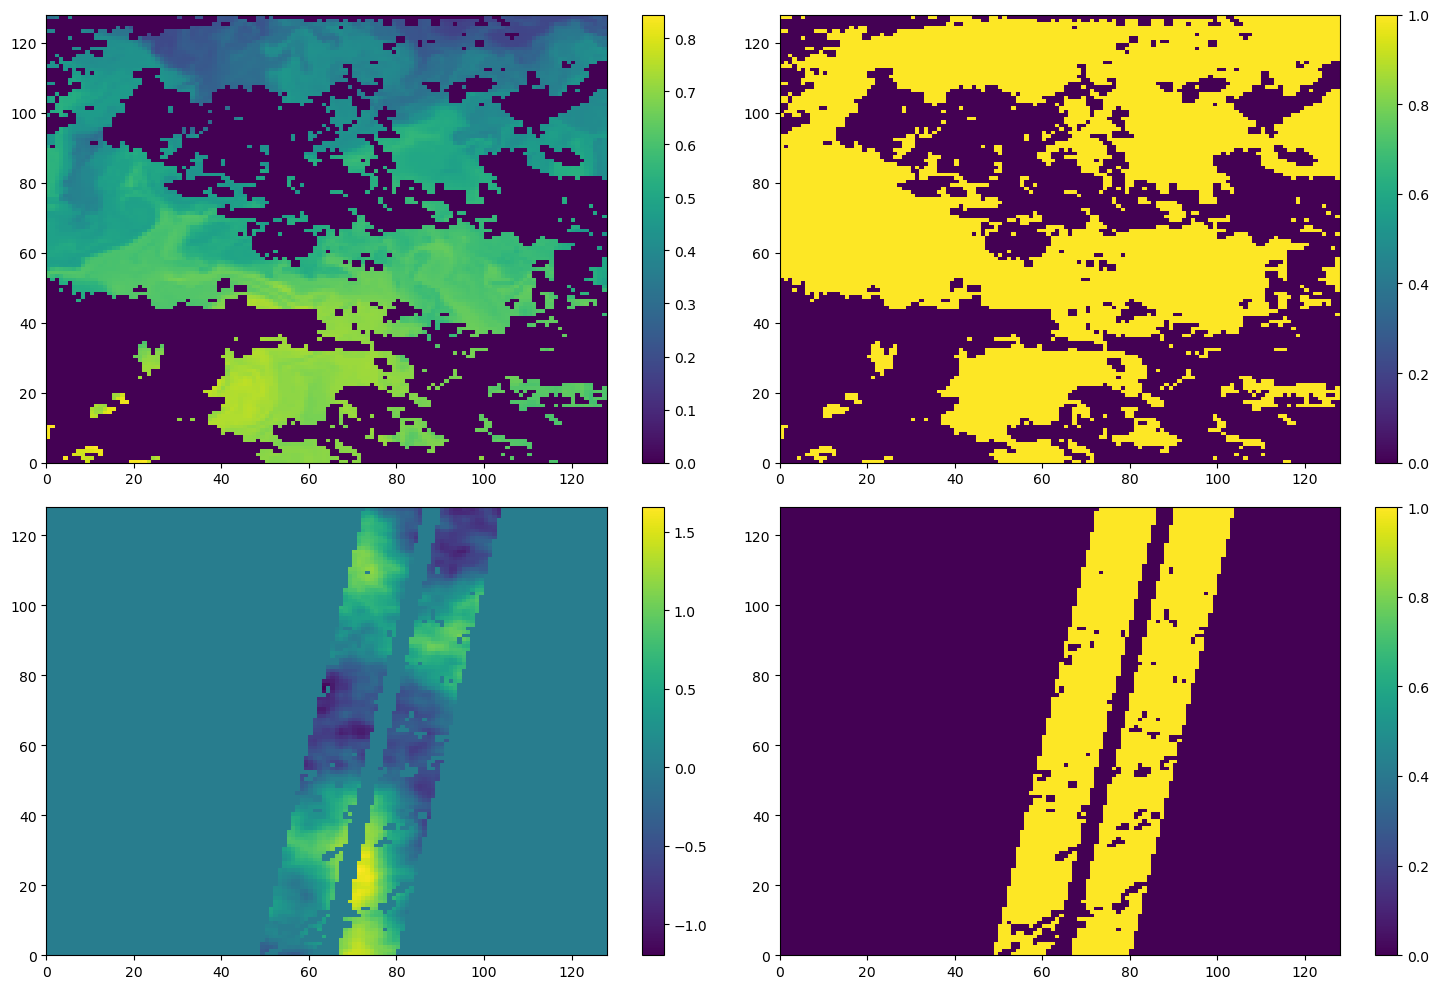

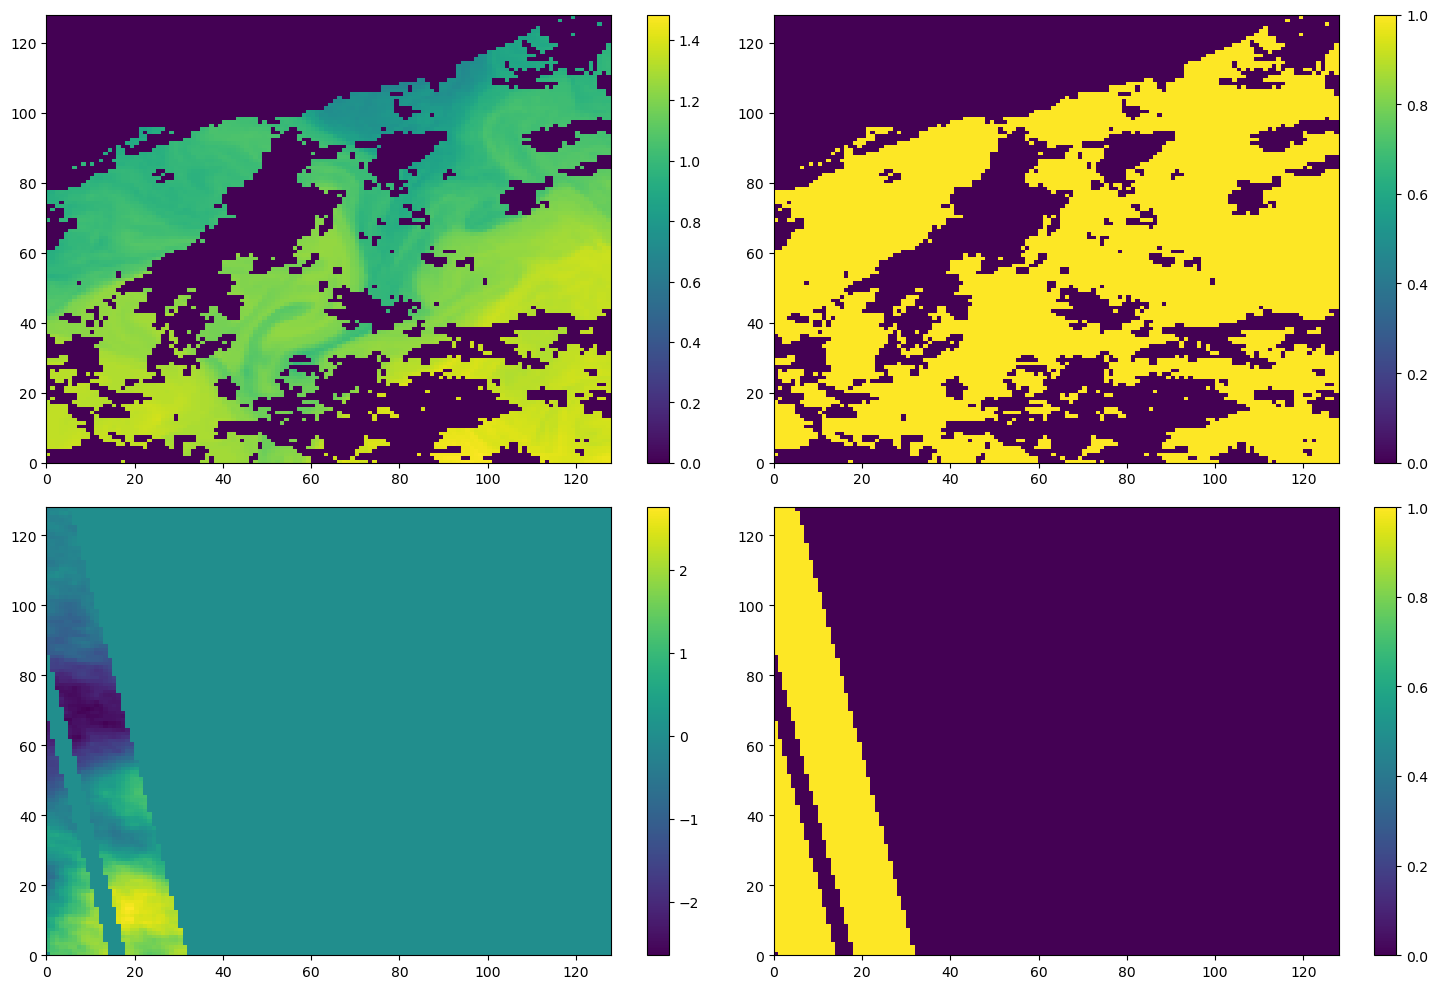

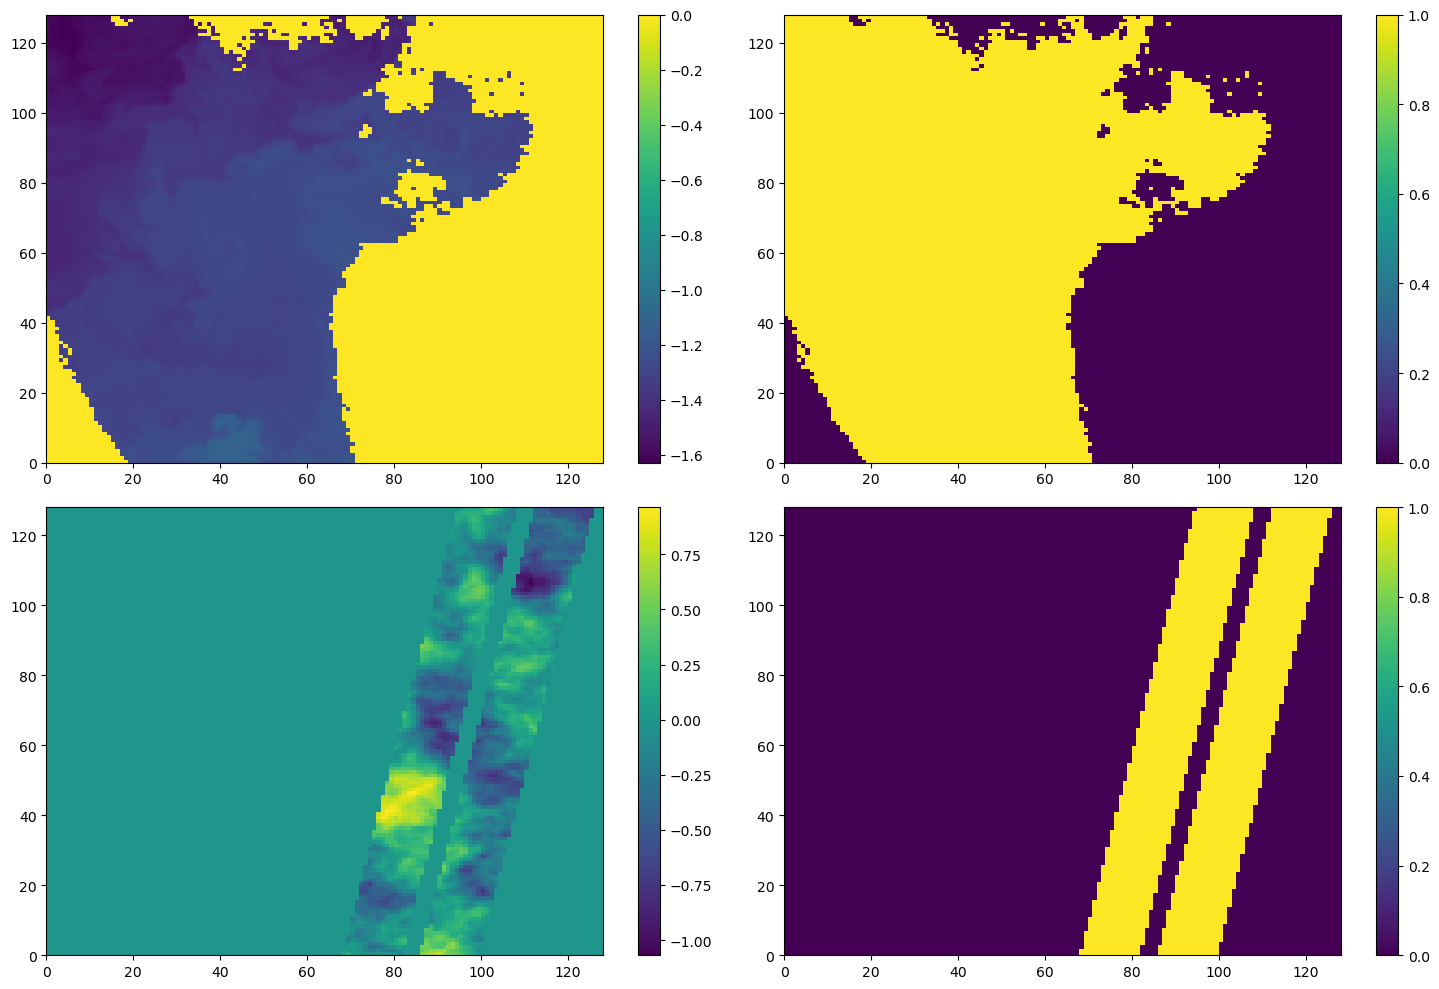

In [6]:
for i in range(len(y_train)):
    fig, axs = plt.subplots(2,2,figsize=(15,10))
    axs = axs.flatten()
    
    im0=axs[0].pcolor(y_train[i,:,:,0].squeeze())
    im1=axs[1].pcolor(A_train[i,:,:,0].squeeze())
    im2=axs[2].pcolor(y_train[i,:,:,1].squeeze())
    im3=axs[3].pcolor(A_train[i,:,:,1].squeeze())
    plt.colorbar(im0,ax=axs[0])
    plt.colorbar(im1,ax=axs[1])
    plt.colorbar(im2,ax=axs[2])
    plt.colorbar(im3,ax=axs[3]) 

    fig.tight_layout()
    plt.show()
    plt.close()